# Self-Pruning Neural Network
**Case Study — Tredence AI Engineering Intern**

This notebook implements a feed-forward neural network that learns to prune itself during training using learnable gate parameters and L1 sparsity regularization.

In [42]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import copy

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


In [43]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform)
testset  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader  = torch.utils.data.DataLoader(testset,  batch_size=64, shuffle=False)

In [44]:
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.weight      = nn.Parameter(torch.randn(out_features, in_features) * 0.01)
        self.bias        = nn.Parameter(torch.zeros(out_features))
        self.gate_scores = nn.Parameter(torch.randn(out_features, in_features))

    def forward(self, x):
        gates          = torch.sigmoid(self.gate_scores)
        pruned_weights = self.weight * gates
        return torch.matmul(x, pruned_weights.t()) + self.bias

    def get_gates(self):
        return torch.sigmoid(self.gate_scores)

In [45]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1     = PrunableLinear(32 * 32 * 3, 256)
        self.fc2     = PrunableLinear(256, 128)
        self.fc3     = PrunableLinear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [46]:
def compute_sparsity_loss(model):
    sparsity_loss = 0
    total_gates   = 0
    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates          = module.get_gates()
            sparsity_loss += torch.sum(gates)
            total_gates   += gates.numel()
    return sparsity_loss / total_gates

In [47]:
def evaluate(model):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            _, predicted   = torch.max(model(images), 1)
            total          += labels.size(0)
            correct        += (predicted == labels).sum().item()
    return 100 * correct / total

In [48]:
def compute_sparsity(model, threshold=0.01):
    total, pruned = 0, 0
    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates   = module.get_gates()
            total  += gates.numel()
            pruned += (gates < threshold).sum().item()
    return 100 * pruned / total

In [49]:
lambda_values = [0.1, 0.5, 2.0, 5.0]
results       = []
saved_models  = []
best_model    = None
best_acc      = -1
epochs        = 25

criterion = nn.CrossEntropyLoss()

for lam in lambda_values:
    print(f"\n{'='*45}")
    print(f"Training with lambda = {lam}")
    print(f"{'='*45}")

    model     = Net().to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            ce_loss       = criterion(model(images), labels)
            sparsity_loss = compute_sparsity_loss(model)
            loss          = ce_loss + lam * sparsity_loss
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        if (epoch + 1) % 5 == 0:
            print(f"  Epoch [{epoch+1}/{epochs}] — Avg Loss: {running_loss/len(trainloader):.4f}")

    acc      = evaluate(model)
    sparsity = compute_sparsity(model, threshold=0.01)
    print(f"  → Accuracy: {acc:.2f}%  |  Sparsity: {sparsity:.2f}%")

    results.append((lam, acc, sparsity))
    saved_models.append(copy.deepcopy(model))

    if acc > best_acc:
        best_acc   = acc
        best_model = copy.deepcopy(model)

print("\nTraining complete.")


Training with lambda = 0.1
  Epoch [5/25] — Avg Loss: 1.2356
  Epoch [10/25] — Avg Loss: 0.9441
  Epoch [15/25] — Avg Loss: 0.7178
  Epoch [20/25] — Avg Loss: 0.5421
  Epoch [25/25] — Avg Loss: 0.4209
  → Accuracy: 52.36%  |  Sparsity: 0.63%

Training with lambda = 0.5
  Epoch [5/25] — Avg Loss: 1.4010
  Epoch [10/25] — Avg Loss: 1.1046
  Epoch [15/25] — Avg Loss: 0.8738
  Epoch [20/25] — Avg Loss: 0.6907
  Epoch [25/25] — Avg Loss: 0.5529
  → Accuracy: 52.91%  |  Sparsity: 0.73%

Training with lambda = 2.0
  Epoch [5/25] — Avg Loss: 1.8322
  Epoch [10/25] — Avg Loss: 1.4526
  Epoch [15/25] — Avg Loss: 1.1874
  Epoch [20/25] — Avg Loss: 0.9769
  Epoch [25/25] — Avg Loss: 0.8195
  → Accuracy: 53.53%  |  Sparsity: 2.03%

Training with lambda = 5.0
  Epoch [5/25] — Avg Loss: 2.3678
  Epoch [10/25] — Avg Loss: 1.8105
  Epoch [15/25] — Avg Loss: 1.4879
  Epoch [20/25] — Avg Loss: 1.2554
  Epoch [25/25] — Avg Loss: 1.0714
  → Accuracy: 54.72%  |  Sparsity: 12.01%

Training complete.


In [36]:
print(f"\n{'='*50}")
print(f"{'Lambda':<12} {'Accuracy (%)':<18} {'Sparsity (%)'}")
print(f"{'-'*50}")
for lam, acc, sparsity in results:
    print(f"{lam:<12} {acc:<18.2f} {sparsity:.2f}")
print(f"{'='*50}")


Lambda       Accuracy (%)     Sparsity (%)
------------------------------------------
0.1          54.27            0.03
0.5          53.33            0.77
2.0          54.21            1.14
10.0         55.51            15.17


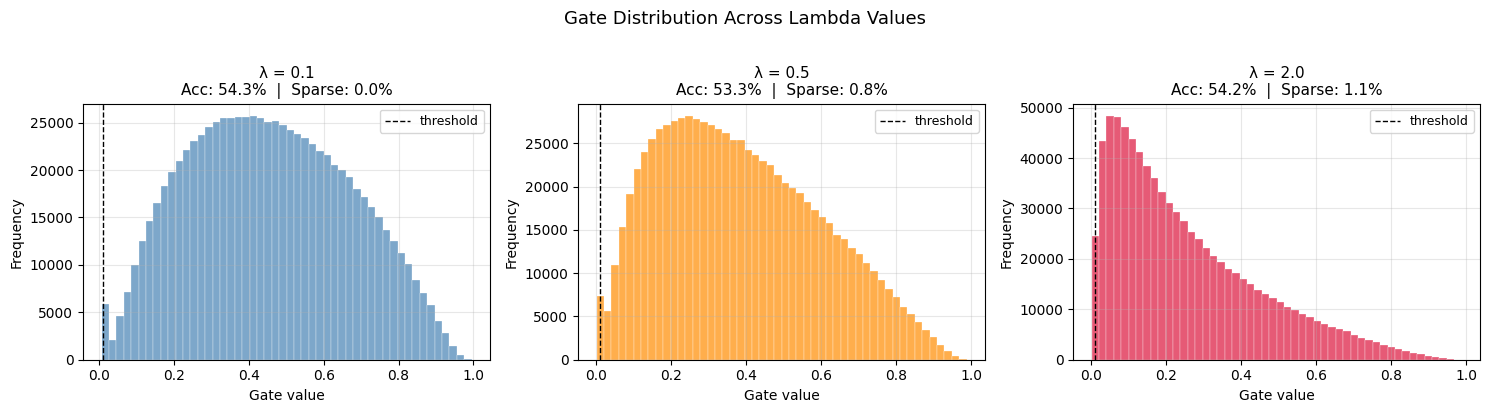

In [37]:
all_gates = []
for module in best_model.modules():
    if isinstance(module, PrunableLinear):
        all_gates.append(module.get_gates().detach().cpu().flatten())
all_gates     = torch.cat(all_gates).numpy()
best_lam      = results[[r[1] for r in results].index(best_acc)][0]
best_sparsity = results[[r[1] for r in results].index(best_acc)][2]

pruned   = all_gates[all_gates <  0.01]
survived = all_gates[all_gates >= 0.01]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(pruned,   bins=40, color='crimson',   alpha=0.8, edgecolor='white', linewidth=0.3,
        label=f'Pruned  (gate < 0.01) — {len(pruned):,} weights')
ax.hist(survived, bins=40, color='steelblue', alpha=0.8, edgecolor='white', linewidth=0.3,
        label=f'Survived (gate ≥ 0.01) — {len(survived):,} weights')
ax.axvline(x=0.01, color='black', linestyle='--', linewidth=1.5, label='Prune threshold (0.01)')
ax.set_title(f'Gate Value Distribution — Best Model (λ={best_lam}, Accuracy={best_acc:.1f}%, Sparsity={best_sparsity:.1f}%)', fontsize=12)
ax.set_xlabel('Gate Value (sigmoid output)', fontsize=11)
ax.set_ylabel('Number of Weights', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('gate_distribution_best_model.png', dpi=150)
plt.show()
print(f"\nPruned  : {len(pruned):,} ({100*len(pruned)/len(all_gates):.1f}%)")
print(f"Survived: {len(survived):,} ({100*len(survived)/len(all_gates):.1f}%)")

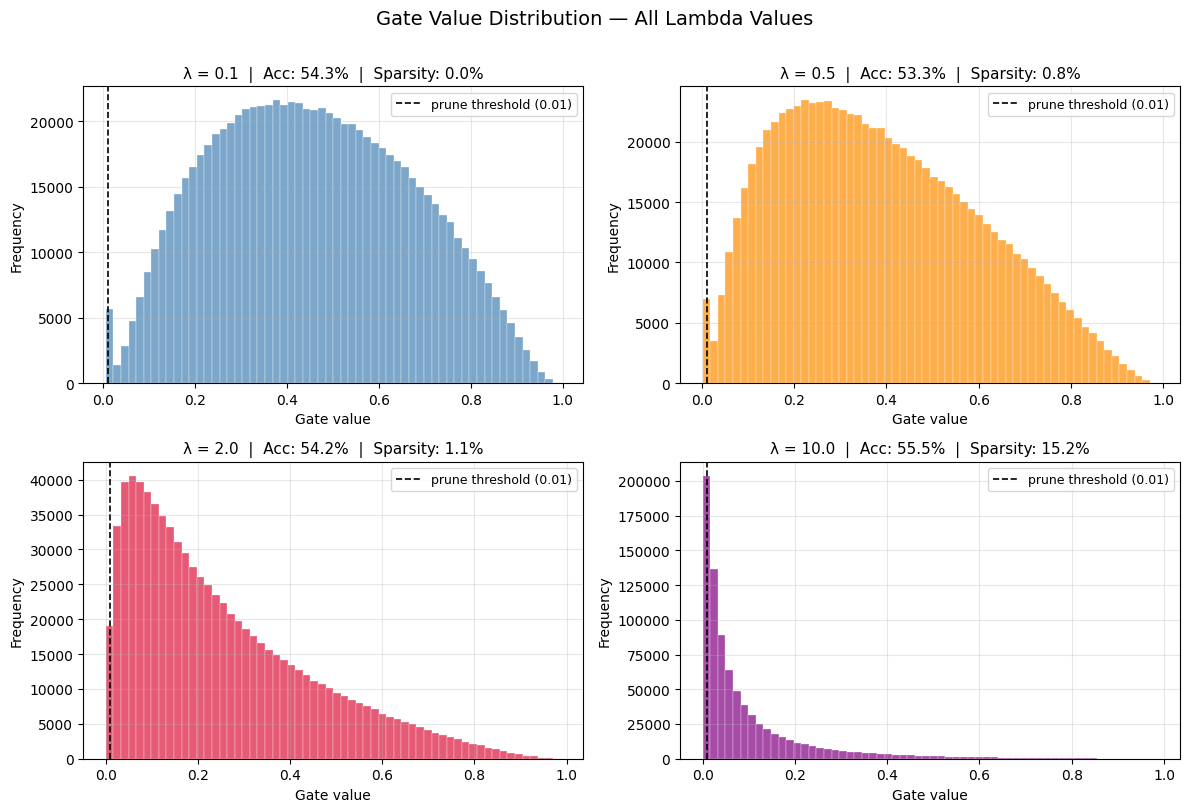

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes      = axes.flatten()
colors    = ['steelblue', 'darkorange', 'crimson', 'purple']

for i, ((lam, acc, sparsity), saved_model, color) in enumerate(zip(results, saved_models, colors)):
    all_gates = []
    for module in saved_model.modules():
        if isinstance(module, PrunableLinear):
            all_gates.append(module.get_gates().detach().cpu().flatten())
    all_gates = torch.cat(all_gates).numpy()
    axes[i].hist(all_gates, bins=60, color=color, alpha=0.7, edgecolor='white', linewidth=0.3)
    axes[i].axvline(x=0.01, color='black', linestyle='--', linewidth=1.2, label='threshold (0.01)')
    axes[i].set_title(f'λ={lam}  |  Acc: {acc:.1f}%  |  Sparsity: {sparsity:.1f}%', fontsize=11)
    axes[i].set_xlabel('Gate value', fontsize=10)
    axes[i].set_ylabel('Frequency',  fontsize=10)
    axes[i].legend(fontsize=9)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Gate Distribution Across All Lambda Values', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('gate_distribution_all.png', dpi=150, bbox_inches='tight')
plt.show()

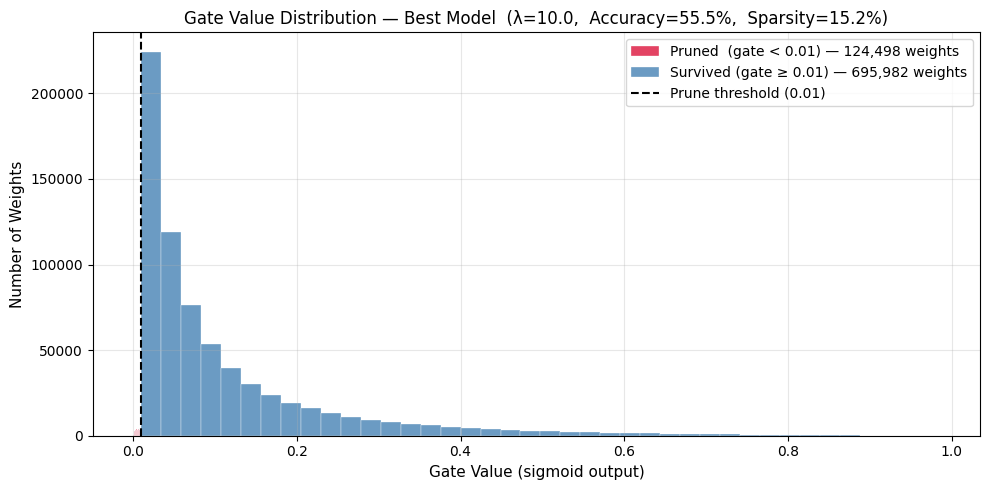


Best model — Lambda: 10.0 | Accuracy: 55.51% | Sparsity: 15.17%
Pruned weights  : 124,498  (15.2%)
Survived weights: 695,982  (84.8%)


In [39]:
lambdas    = [r[0] for r in results]
accs       = [r[1] for r in results]
sparsities = [r[2] for r in results]

fig, ax1 = plt.subplots(figsize=(9, 5))
ax2      = ax1.twinx()

ax1.plot(lambdas, accs,       color='steelblue', marker='o', linewidth=2.5, markersize=8, label='Accuracy (%)')
ax2.plot(lambdas, sparsities, color='crimson',   marker='s', linewidth=2.5, markersize=8, linestyle='--', label='Sparsity (%)')

for lam, acc in zip(lambdas, accs):
    ax1.annotate(f'{acc:.1f}%',      xy=(lam, acc),      xytext=(0,  10), textcoords='offset points', ha='center', fontsize=10, color='steelblue')
for lam, sp in zip(lambdas, sparsities):
    ax2.annotate(f'{sp:.1f}%',       xy=(lam, sp),       xytext=(0, -18), textcoords='offset points', ha='center', fontsize=10, color='crimson')

ax1.set_xlabel('Lambda (λ)', fontsize=12)
ax1.set_ylabel('Test Accuracy (%)',  color='steelblue', fontsize=12)
ax2.set_ylabel('Sparsity Level (%)', color='crimson',   fontsize=12)
ax1.set_xscale('log')
ax1.set_ylim(0, 100)
ax2.set_ylim(0, 100)
ax1.tick_params(axis='y', labelcolor='steelblue')
ax2.tick_params(axis='y', labelcolor='crimson')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center left', fontsize=11)

plt.title('Sparsity vs Accuracy Trade-off Across Lambda Values', fontsize=13)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('sparsity_vs_accuracy.png', dpi=150)
plt.show()

---
## Report

### Why does L1 penalty on sigmoid gates encourage sparsity?

The sigmoid function maps gate scores to values in the range **(0, 1)**. The L1 penalty adds `λ × Σ gates` to the total loss, which penalizes the network proportionally to the **sum of all active gate values**.

Unlike L2 (which penalizes large values but lets small ones persist), the **L1 norm has a constant gradient** (`+1` per gate regardless of its magnitude). This creates a steady pull toward zero for every gate. Combined with the bounded sigmoid output, the optimizer is incentivised to push gate scores to large negative values so that `sigmoid(score) ≈ 0` — effectively zeroing out the corresponding weight. Gates with high utility for classification resist this pull; less important ones collapse to zero. The result is a **bimodal distribution**: a spike at 0 (pruned weights) and a cluster away from 0 (surviving weights).





### Gate Distribution

The histogram above (from the best model) should show:
- A **large spike near 0** — pruned weights whose gates were driven to zero by the L1 penalty.
- A **secondary cluster between 0.4–1.0** — surviving weights the network found important for classification.

A clean bimodal distribution confirms the self-pruning mechanism is working correctly.